# 135-Model Framework: Three-State Kalman Filter

## Three-State Kalman Filter

### State Vector
$$\mathbf{x}_t = \begin{bmatrix} \mu \\ m \\ b \end{bmatrix}$$

- $\mu$: Fast state (current duration estimate)
- $m$: Slow state (prior mean / running average)
- $b$: Bias state (serial dependence)

### State Transition
$$\mathbf{x}_t^- = F \mathbf{x}_{t-1} = \begin{bmatrix} 0 & 1 & F_{02} \\ 0 & 1 & 0 \\ 0 & 0 & \lambda \end{bmatrix} \begin{bmatrix} \mu \\ m \\ b \end{bmatrix}_{t-1}$$

### Observation Model
$$z_t = H \mathbf{x}_t + v_t, \quad H = [1, 0, 0], \quad v_t \sim \mathcal{N}(0, R)$$

### Kalman Filter Equations

**Predict:**
$$\mathbf{x}_t^- = F \mathbf{x}_{t-1}, \quad P_t^- = F P_{t-1} F^\top + Q$$

**Update:**
$$K_t = P_t^- H^\top (H P_t^- H^\top + R)^{-1}$$
$$\mathbf{x}_t = \mathbf{x}_t^- + K_t (z_t - H \mathbf{x}_t^-)$$
$$P_t = (I - K_t H) P_t^-$$

**Response:**
$$y_t = \mu_t + d_0 \quad \text{(or } y_t = \mu_t + b_t + d_0 \text{ for B3)}$$

---

## Model Space: C(15) × S(3) × B(3) = 135 Models

This notebook uses:
- **Exponential coherence modulation** for Q parameters
- **Binary step function** for R modulation

$$Q_i(c) = q_{i,base} \times e^{\alpha_{q_i} \times (1-c)}$$
$$R(c) = \begin{cases} 1 & \text{if } c \geq 0.5 \\ r_{low} & \text{if } c < 0.5 \end{cases}$$

### B-Axis: Bias Mechanism (3 levels)

| ID | Name | F[0,2] | Response | Description |
|----|------|--------|----------|-------------|
| B1 | B1 | 0 | y = μ + d0 | Bias via KF update only |
| B2 | B2 | 1 | y = μ + d0 | Bias in prediction (μ⁻ = m + b) |
| B3 | B3 | 0 | y = μ + b + d0 | Bias in response only |

---
## 1. Setup

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr
import warnings
import gc
import time
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='ticks', context='paper')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 8)

print('Libraries loaded')

Libraries loaded


In [74]:
# Import 135-model framework (NO LOG TRANSFORM version)
import sys
import importlib
from pathlib import Path

# Add three_state_kalman to path so module can be imported directly
sys.path.insert(0, str(Path('three_state_kalman').resolve()))

import three_state_135_nolog
importlib.reload(three_state_135_nolog)

from three_state_135_nolog import (
    # Configuration
    C_AXIS, S_AXIS, B_AXIS, N_MODELS,
    get_all_models, get_model_by_id, print_model_space,
    get_parameter_config, get_param_count_by_model,
    
    # Fitting
    fit_all_subjects, fit_single_model,
    fit_all_subjects_incremental,
    
    # Model comparison
    get_best_model, rank_models, compare_axes,
    
    # PPC
    generate_ppc_single_subject, compute_ppc_metrics,
)

print(f'Loaded three_state_135_nolog module: {N_MODELS} models')
print(f'NO LOG TRANSFORM - operating in original duration space')
print(f'Coherence formula:')
print(f'  Q(c) = Q_base × exp(α × (1 - c))')
print(f'  R(c) = 1 if c >= 0.5, r_low if c < 0.5')

Loaded three_state_135_nolog module: 135 models
NO LOG TRANSFORM - operating in original duration space
Coherence formula:
  Q(c) = Q_base × exp(α × (1 - c))
  R(c) = 1 if c >= 0.5, r_low if c < 0.5


In [75]:
# Display model space
print_model_space()

THREE-STATE 135-MODEL COMPOSITIONAL SPACE

Total: N = |C| × |S| × |B| = 15 × 3 × 3 = 135

----------------------------------------------------------------------
C-AXIS: Coherence Modulation Targets (15 levels)
----------------------------------------------------------------------
ID    Name         Q1   Q2   Q3   R    Description
----------------------------------------------------------------------
C1    Q1           ✓    -    -    -    Fast state process noise modulated
C2    Q2           -    ✓    -    -    Slow state process noise modulated
C3    Q3           -    -    ✓    -    Bias state process noise modulated
C4    R            -    -    -    ✓    Measurement noise modulated
C5    Q1_R         ✓    -    -    ✓    Fast state + measurement noise
C6    Q2_R         -    ✓    -    ✓    Slow state + measurement noise
C7    Q3_R         -    -    ✓    ✓    Bias state + measurement noise
C8    Q1_Q2        ✓    ✓    -    -    Fast + slow state process noise
C9    Q1_Q3        ✓    -  

In [76]:
# Show B-axis details
print('\n' + '='*70)
print('B-AXIS DETAILS')
print('='*70)
for b_id, b_cfg in B_AXIS.items():
    print(f"\n{b_id}: {b_cfg['name']}")
    print(f"  Description: {b_cfg['description']}")
    print(f"  F[0,2] = {b_cfg['F_02']} → μ⁻ = m{' + b' if b_cfg['F_02'] == 1.0 else ''}")
    print(f"  response_bias = {b_cfg['response_bias']} → y = μ{' + b' if b_cfg['response_bias'] else ''} + d0")


B-AXIS DETAILS

B1: B1
  Description: Bias in prediction only (F[0,2]=0, response=μ+d0)
  F[0,2] = 0.0 → μ⁻ = m
  response_bias = False → y = μ + d0

B2: B2
  Description: Bias in prediction via F (F[0,2]=1, response=μ+d0)
  F[0,2] = 1.0 → μ⁻ = m + b
  response_bias = False → y = μ + d0

B3: B3
  Description: Bias in response only (F[0,2]=0, response=μ+b+d0)
  F[0,2] = 0.0 → μ⁻ = m
  response_bias = True → y = μ + b + d0


---
## 2. Load Data

In [77]:
# Paths (notebook runs from modeling/ directory)
NB_DIR = Path().resolve()          # modeling/
root = NB_DIR.parent               # repo root
data_path = root / 'analysis'
output_path = NB_DIR / 'three_state_kalman' / 'Output_135Model'
output_path.mkdir(parents=True, exist_ok=True)

# Load and preprocess data
same_set = {'HH', 'LL'}

exp1 = (pd.read_pickle(data_path / 'experiment1' / 'E1.pkl')
        .query('~is_outlier')
        .assign(exp=1,
                Structure=lambda df: np.where(df['TransitionType'].isin(same_set), 'Repeat', 'Switch'))
        .rename(columns={'curDur': 'Duration', 'curBias': 'Bias', 'rpr': 'Reproduction',
                         'curCoherence': 'coherence', 'subID': 'Sub'})
        .assign(Sub=lambda df: df['Sub'].str.lstrip('S').astype(int))
        .astype({'coherence': float}))

exp2 = (pd.read_pickle(data_path / 'experiment2' / 'E2.pkl')
        .query('~is_outlier')
        .assign(exp=2,
                Structure=lambda df: np.where(df['TransitionType'].isin(same_set), 'Repeat', 'Switch'))
        .rename(columns={'curDur': 'Duration', 'curBias': 'Bias', 'rpr': 'Reproduction',
                         'curCoherence': 'coherence', 'subID': 'Sub'})
        .assign(Sub=lambda df: df['Sub'].str.lstrip('S').astype(int))
        .astype({'coherence': float}))

df = pd.concat([exp1, exp2], ignore_index=True)[[
    'Sub', 'exp', 'trial_num', 'coherence', 'Structure',
    'Duration', 'Bias', 'Reproduction'
]]

print(f'Data loaded: {len(df):,} trials')
print(f'  Exp1 (Dynamic Coherence): {len(exp1):,} trials, {exp1["Sub"].nunique()} subjects')
print(f'  Exp2 (Fixed Coherence):   {len(exp2):,} trials, {exp2["Sub"].nunique()} subjects')

Data loaded: 9,308 trials
  Exp1 (Dynamic Coherence): 4,670 trials, 22 subjects
  Exp2 (Fixed Coherence):   4,638 trials, 22 subjects


---
## 3. Model Fitting

Using batch checkpoint strategy for reliable fitting.

In [78]:
# ── Fixed column set (prevents CSV column mismatch) ──────────────────
ALL_COLUMNS = sorted([
    # base params
    'q1', 'q2', 'q3', 'lambda', 'r_base', 'd0', 'alpha_d0',
    # C-axis modulation params
    'alpha_q1', 'alpha_q2', 'alpha_q3', 'r_low',
    # S-axis params
    'x_reset', 'k_reset',
    # metadata
    'model_id', 'model_name', 'c_id', 's_id', 'b_id',
    'n_params', 'AIC', 'BIC', 'RMSE', 'DW', 'RSS', 'N',
    'success', 'Sub', 'exp',
])

# ── Batch config ─────────────────────────────────────────────────────
BATCH_SIZE = 15  # 135 models / 15 = 9 batches
all_models = get_all_models()
n_batches = len(all_models) // BATCH_SIZE
batches = [all_models[i*BATCH_SIZE:(i+1)*BATCH_SIZE] for i in range(n_batches)]

CKPT_DIR = output_path / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

def ckpt_path(exp_num, sub, batch_id):
    return CKPT_DIR / f'exp{exp_num}_sub{sub}_batch{batch_id:02d}.csv'

def fit_and_save_batch(stimrep, coherence, structure, sub, exp_num, batch_id, models):
    """Fit one batch, save with fixed columns, return nothing (saves memory)."""
    results = []
    for m in models:
        seed = hash((sub, exp_num, m['model_id'])) % (2**31)
        r = fit_single_model(stimrep, coherence, structure,
                             m['c_id'], m['s_id'], m['b_id'], seed=seed)
        r['Sub'] = sub
        r['exp'] = exp_num
        results.append(r)
    batch_df = pd.DataFrame(results).reindex(columns=ALL_COLUMNS)
    batch_df.to_csv(ckpt_path(exp_num, sub, batch_id), index=False)

print(f'{len(all_models)} models -> {n_batches} batches x {BATCH_SIZE}')
print(f'Checkpoint dir: {CKPT_DIR}')

135 models -> 9 batches x 15
Checkpoint dir: /Users/chunyu/Documents/GitHub/precision-weighting-serial-dependence/modeling/three_state_kalman/Output_135Model/checkpoints


In [79]:
# ── Settings ─────────────────────────────────────────────────────────
FORCE_REFIT = False  # Results already computed — set True to refit from scratch

# ── Check existing checkpoint progress ───────────────────────────────
def count_completed_checkpoints(exp_num, subjects):
    """Count how many subject×batch checkpoints exist for an experiment."""
    done = 0
    for sub in subjects:
        for batch_id in range(n_batches):
            if ckpt_path(exp_num, sub, batch_id).exists():
                done += 1
    return done

# Count progress
exp1_subs = sorted(df[df['exp'] == 1]['Sub'].unique())
exp2_subs = sorted(df[df['exp'] == 2]['Sub'].unique())

n_total_exp1 = len(exp1_subs) * n_batches
n_total_exp2 = len(exp2_subs) * n_batches

n_done_exp1 = count_completed_checkpoints(1, exp1_subs)
n_done_exp2 = count_completed_checkpoints(2, exp2_subs)

print('CHECKPOINT PROGRESS')
print('=' * 60)
print(f'Exp1: {n_done_exp1:3d} / {n_total_exp1} checkpoints ({100*n_done_exp1/n_total_exp1:.1f}%)')
print(f'Exp2: {n_done_exp2:3d} / {n_total_exp2} checkpoints ({100*n_done_exp2/n_total_exp2:.1f}%)')

if FORCE_REFIT:
    print('\n⚠ FORCE_REFIT=True → will delete all checkpoints and start fresh')

CHECKPOINT PROGRESS
Exp1:   0 / 198 checkpoints (0.0%)
Exp2:   0 / 198 checkpoints (0.0%)


In [80]:
# Skip fitting if final results already exist
if (output_path / '135model_fits.csv').exists() and not FORCE_REFIT:
    print('✓ Results already exist — skipping fitting.')
    print(f'  → {output_path / "135model_fits.csv"}')
else:
    # ══════════════════════════════════════════════════════════════════════
    # RUN FITTING (checkpoint-based, resume-safe)
    # ══════════════════════════════════════════════════════════════════════
    
    import shutil
    
    # If FORCE_REFIT, clear all checkpoints first
    if FORCE_REFIT:
        if CKPT_DIR.exists():
            shutil.rmtree(CKPT_DIR)
            CKPT_DIR.mkdir(parents=True, exist_ok=True)
        print('✓ Cleared all checkpoints\n')
    
    print('=' * 70)
    print('135-MODEL FITTING — BINARY R MODULATION')
    print('=' * 70)
    print(f'  Formula: Q(c) = Q_base × exp(α × (1 - c))')
    print(f'           R(c) = 1 if c >= 0.5, r_low if c < 0.5')
    print(f'  {len(all_models)} models × (22 + 22) subjects = {len(all_models)*44} total fits')
    print(f'  {n_batches} batches × {BATCH_SIZE} models/batch per subject')
    print()
    
    # ── Main fitting loop ────────────────────────────────────────────────
    for exp_num in [1, 2]:
        print(f'\n{"="*70}')
        print(f'>>> EXPERIMENT {exp_num}')
        print('=' * 70)
        
        exp_data = df[df['exp'] == exp_num]
        subjects = sorted(exp_data['Sub'].unique())
        
        for sub_idx, sub in enumerate(subjects, 1):
            sub_data = exp_data[exp_data['Sub'] == sub]
            stimrep = sub_data[['Duration', 'Reproduction']].values
            coherence = sub_data['coherence'].values
            structure = sub_data['Structure'].values
            
            # Count pending batches
            pending = [b for b in range(n_batches) if not ckpt_path(exp_num, sub, b).exists()]
            if not pending:
                continue  # All batches done for this subject
            
            print(f'\n[Exp{exp_num}] Subject {sub} ({sub_idx}/{len(subjects)}): {len(pending)} batches pending')
            
            for batch_id in pending:
                batch_models = batches[batch_id]
                print(f'  Batch {batch_id+1:2d}/{n_batches}: ', end='', flush=True)
                t0 = time.time()
                
                fit_and_save_batch(stimrep, coherence, structure, sub, exp_num, batch_id, batch_models)
                
                print(f'✓ ({time.time()-t0:.1f}s)')
                gc.collect()
    
    print('\n' + '=' * 70)
    print('✓ FITTING COMPLETE')
    print('=' * 70)

✓ Results already exist — skipping fitting.
  → /Users/chunyu/Documents/GitHub/precision-weighting-serial-dependence/modeling/three_state_kalman/Output_135Model/135model_fits.csv


### Merge Checkpoints

Combine all batch checkpoints into a single results file for analysis.

In [81]:
# ══════════════════════════════════════════════════════════════════════
# LOAD RESULTS (from pre-computed CSV or merged from checkpoints)
# ══════════════════════════════════════════════════════════════════════

final_csv = output_path / '135model_fits.csv'

if final_csv.exists():
    # Pre-computed results available — load directly
    results_df = pd.read_csv(final_csv)
    # Align Sub format with df (df uses int, CSV stores 'S01' strings)
    results_df['Sub'] = results_df['Sub'].astype(str).str.lstrip('S').astype(int)
    print('=' * 70)
    print('LOADED PRE-COMPUTED RESULTS')
    print('=' * 70)
    print(f'Exp1 (Dynamic Coherence): {len(results_df[results_df["exp"]==1]):,} fits, {results_df[results_df["exp"]==1]["Sub"].nunique()} subjects')
    print(f'Exp2 (Fixed Coherence):   {len(results_df[results_df["exp"]==2]):,} fits, {results_df[results_df["exp"]==2]["Sub"].nunique()} subjects')
    print(f'Total: {len(results_df):,} fits')
else:
    # Merge from checkpoints
    def merge_checkpoints(exp_num, subjects):
        dfs = []
        for sub in subjects:
            for batch_id in range(n_batches):
                p = ckpt_path(exp_num, sub, batch_id)
                if p.exists():
                    dfs.append(pd.read_csv(p))
        return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

    results_exp1 = merge_checkpoints(1, exp1_subs)
    results_exp2 = merge_checkpoints(2, exp2_subs)

    if len(results_exp1):
        results_exp1.to_csv(output_path / '135model_exp1.csv', index=False)
    if len(results_exp2):
        results_exp2.to_csv(output_path / '135model_exp2.csv', index=False)

    if len(results_exp1) or len(results_exp2):
        results_df = pd.concat([results_exp1, results_exp2], ignore_index=True)
        results_df.to_csv(final_csv, index=False)
        print(f'Merged: {len(results_df):,} fits saved to {final_csv}')
    else:
        results_df = None
        print('⚠ No results found. Run the fitting cell first.')

LOADED PRE-COMPUTED RESULTS
Exp1 (Dynamic Coherence): 2,970 fits, 22 subjects
Exp2 (Fixed Coherence):   2,970 fits, 22 subjects
Total: 5,940 fits


---
## 4. Model Comparison

In [82]:
if results_df is not None:
    print('='*70)
    print('MODEL COMPARISON RESULTS')
    print('='*70)
    
    for exp_num in [1, 2]:
        print(f'\n### Experiment {exp_num} ###\n')
        
        # Rank models
        ranking = rank_models(results_df, exp_num=exp_num, criterion='AIC')
        
        # Top 10
        print('Top 10 Models by AIC:')
        display(ranking.head(10)[['Rank', 'model_name', 'c_id', 's_id', 'b_id',
                                   'AIC', 'delta_AIC', 'BIC', 'RMSE', 'n_params']].round(2))
        
        # Best model
        best = ranking.iloc[0]
        print(f'\nBest: {best["model_name"]} (k={int(best["n_params"])}, AIC={best["AIC"]:.1f})')

MODEL COMPARISON RESULTS

### Experiment 1 ###

Top 10 Models by AIC:


,Rank,model_name,c_id,s_id,b_id,AIC,delta_AIC,BIC,RMSE,n_params
67,1,C_Q1__S_baseline__B_B2,C1,S0,B2,-112.87,0.00,-86.01,0.18,8
121,2,C_Q3__S_baseline__B_B2,C3,S0,B2,-112.59,0.28,-85.73,0.18,8
49,3,C_Q1_Q3__S_baseline__B_B2,C9,S0,B2,-112.01,0.86,-81.79,0.18,9
103,4,C_Q2__S_baseline__B_B2,C2,S0,B2,-111.79,1.08,-84.93,0.18,8
66,5,C_Q1__S_baseline__B_B1,C1,S0,B1,-111.57,1.30,-84.71,0.18,8
68,6,C_Q1__S_baseline__B_B3,C1,S0,B3,-111.55,1.32,-84.69,0.18,8
31,7,C_Q1_Q2__S_baseline__B_B2,C8,S0,B2,-111.21,1.66,-80.99,0.18,9
64,8,C_Q1__S_K_reset__B_B2,C1,S2,B2,-111.14,1.73,-80.92,0.18,9
70,9,C_Q1__S_x_reset__B_B2,C1,S1,B2,-111.05,1.83,-80.83,0.18,9
124,10,C_Q3__S_x_reset__B_B2,C3,S1,B2,-110.90,1.97,-80.68,0.18,9



Best: C_Q1__S_baseline__B_B2 (k=8, AIC=-112.9)

### Experiment 2 ###

Top 10 Models by AIC:


,Rank,model_name,c_id,s_id,b_id,AIC,delta_AIC,BIC,RMSE,n_params
70,1,C_Q1__S_x_reset__B_B2,C1,S1,B2,-73.05,0.00,-42.87,0.2,9
67,2,C_Q1__S_baseline__B_B2,C1,S0,B2,-72.47,0.59,-45.64,0.2,8
124,3,C_Q3__S_x_reset__B_B2,C3,S1,B2,-72.45,0.60,-42.27,0.2,9
52,4,C_Q1_Q3__S_x_reset__B_B2,C9,S1,B2,-72.30,0.75,-38.76,0.2,10
106,5,C_Q2__S_x_reset__B_B2,C2,S1,B2,-72.24,0.81,-42.06,0.2,9
121,6,C_Q3__S_baseline__B_B2,C3,S0,B2,-72.12,0.93,-45.29,0.2,8
103,7,C_Q2__S_baseline__B_B2,C2,S0,B2,-71.76,1.29,-44.94,0.2,8
34,8,C_Q1_Q2__S_x_reset__B_B2,C8,S1,B2,-71.70,1.35,-38.17,0.2,10
49,9,C_Q1_Q3__S_baseline__B_B2,C9,S0,B2,-71.68,1.37,-41.50,0.2,9
61,10,C_Q1_R__S_x_reset__B_B2,C5,S1,B2,-71.37,1.68,-37.84,0.2,10



Best: C_Q1__S_x_reset__B_B2 (k=9, AIC=-73.1)


### Axis Comparison

Compare model performance marginalized over each axis to identify which factors contribute most to fit quality.

In [83]:
# Compare by axis
if results_df is not None:
    for exp_num in [1, 2]:
        print(f'\n{"="*70}')
        print(f'AXIS COMPARISON - Experiment {exp_num}')
        print('='*70)
        
        comparison = compare_axes(results_df, exp_num=exp_num)
        
        print('\n### By C-Axis (Coherence Modulation) ###')
        display(comparison['by_c'])
        
        print('\n### By S-Axis (Switch Effect) ###')
        display(comparison['by_s'])
        
        print('\n### By B-Axis (Bias Mechanism) ###')
        display(comparison['by_b'])


AXIS COMPARISON - Experiment 1

### By C-Axis (Coherence Modulation) ###


,AIC_mean,AIC_min,AIC_std,n_params_mean
c_id,,,,
C1,-110.98,-344.07,97.58,8.67
C2,-109.93,-344.01,97.89,8.67
C3,-109.90,-345.44,98.07,8.67
C9,-109.42,-343.37,97.85,9.67
C8,-109.39,-342.12,97.67,9.67
C4,-109.32,-343.69,96.45,8.67
C5,-108.74,-345.67,97.44,9.67
C10,-108.32,-343.49,98.12,9.67
C14,-107.80,-341.50,97.81,10.67



### By S-Axis (Switch Effect) ###


,AIC_mean,AIC_min,AIC_std
s_id,,,
S0,-109.34,-345.67,97.14
S1,-108.17,-342.47,97.24
S2,-107.63,-345.24,97.28



### By B-Axis (Bias Mechanism) ###


...

,AIC_mean,AIC_min,AIC_std,n_params_mean
c_id,,,,
C1,-70.70,-239.91,79.39,8.67
C2,-70.14,-239.59,79.29,8.67
C8,-69.65,-238.00,79.60,9.67
C3,-69.49,-242.27,79.14,8.67
C4,-69.35,-237.53,78.59,8.67
C9,-69.10,-240.30,79.49,9.67
C5,-68.85,-235.74,79.07,9.67
C10,-68.53,-240.16,79.39,9.67
C6,-68.47,-235.53,78.95,9.67



### By S-Axis (Switch Effect) ###


,AIC_mean,AIC_min,AIC_std
s_id,,,
S1,-69.17,-238.31,79.55
S0,-68.91,-242.27,78.66
S2,-67.55,-240.17,78.96



### By B-Axis (Bias Mechanism) ###


,AIC_mean,AIC_min,AIC_std
b_id,,,
B2,-70.07,-242.27,79.39
B3,-67.78,-237.65,78.88
B1,-67.77,-237.65,78.87


---
## 5. Visualization

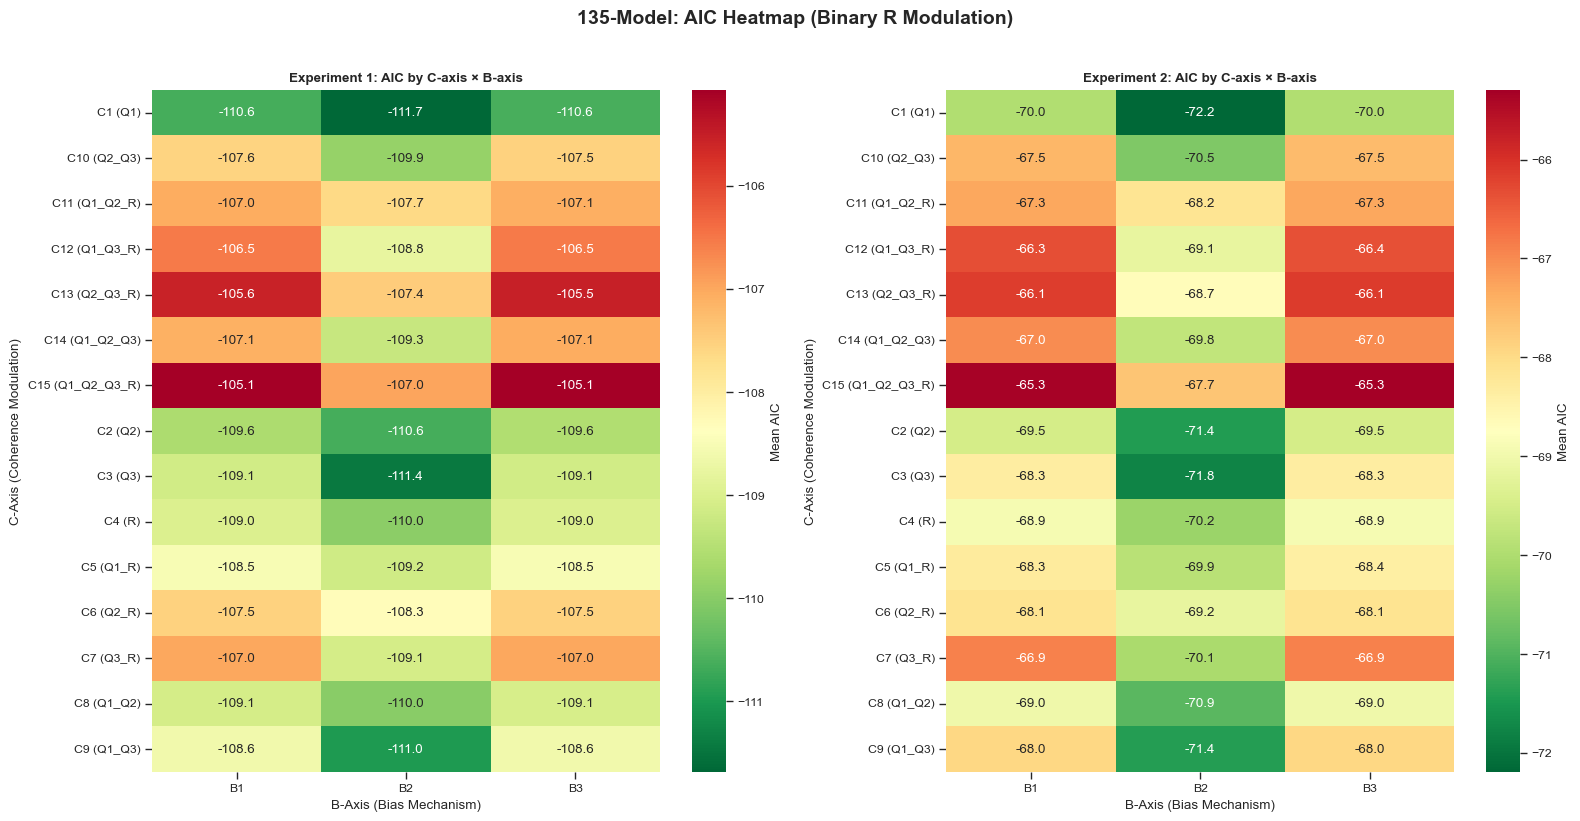

In [84]:
# AIC heatmap by C-axis and B-axis
if results_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    for idx, exp_num in enumerate([1, 2]):
        ax = axes[idx]
        
        exp_data = results_df[results_df['exp'] == exp_num]
        
        # Pivot: C-axis vs B-axis, mean AIC
        pivot = exp_data.groupby(['c_id', 'b_id'])['AIC'].mean().unstack()
        
        # Add C-axis names
        pivot.index = [f"{c} ({C_AXIS[c]['name']})" for c in pivot.index]
        pivot.columns = [B_AXIS[b]['name'] for b in pivot.columns]
        
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', 
                    ax=ax, cbar_kws={'label': 'Mean AIC'})
        ax.set_title(f'Experiment {exp_num}: AIC by C-axis × B-axis', fontweight='bold')
        ax.set_xlabel('B-Axis (Bias Mechanism)')
        ax.set_ylabel('C-Axis (Coherence Modulation)')
    
    plt.suptitle('135-Model: AIC Heatmap (Binary R Modulation)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(output_path / 'aic_heatmap_c_b.png', dpi=150, bbox_inches='tight')
    plt.show()

### Model Ranking

Horizontal bar chart showing ΔAIC for top 50 models. Colors indicate B-axis (bias mechanism). Vertical lines mark conventional thresholds: ΔAIC = 2 (substantial evidence) and ΔAIC = 10 (strong evidence).

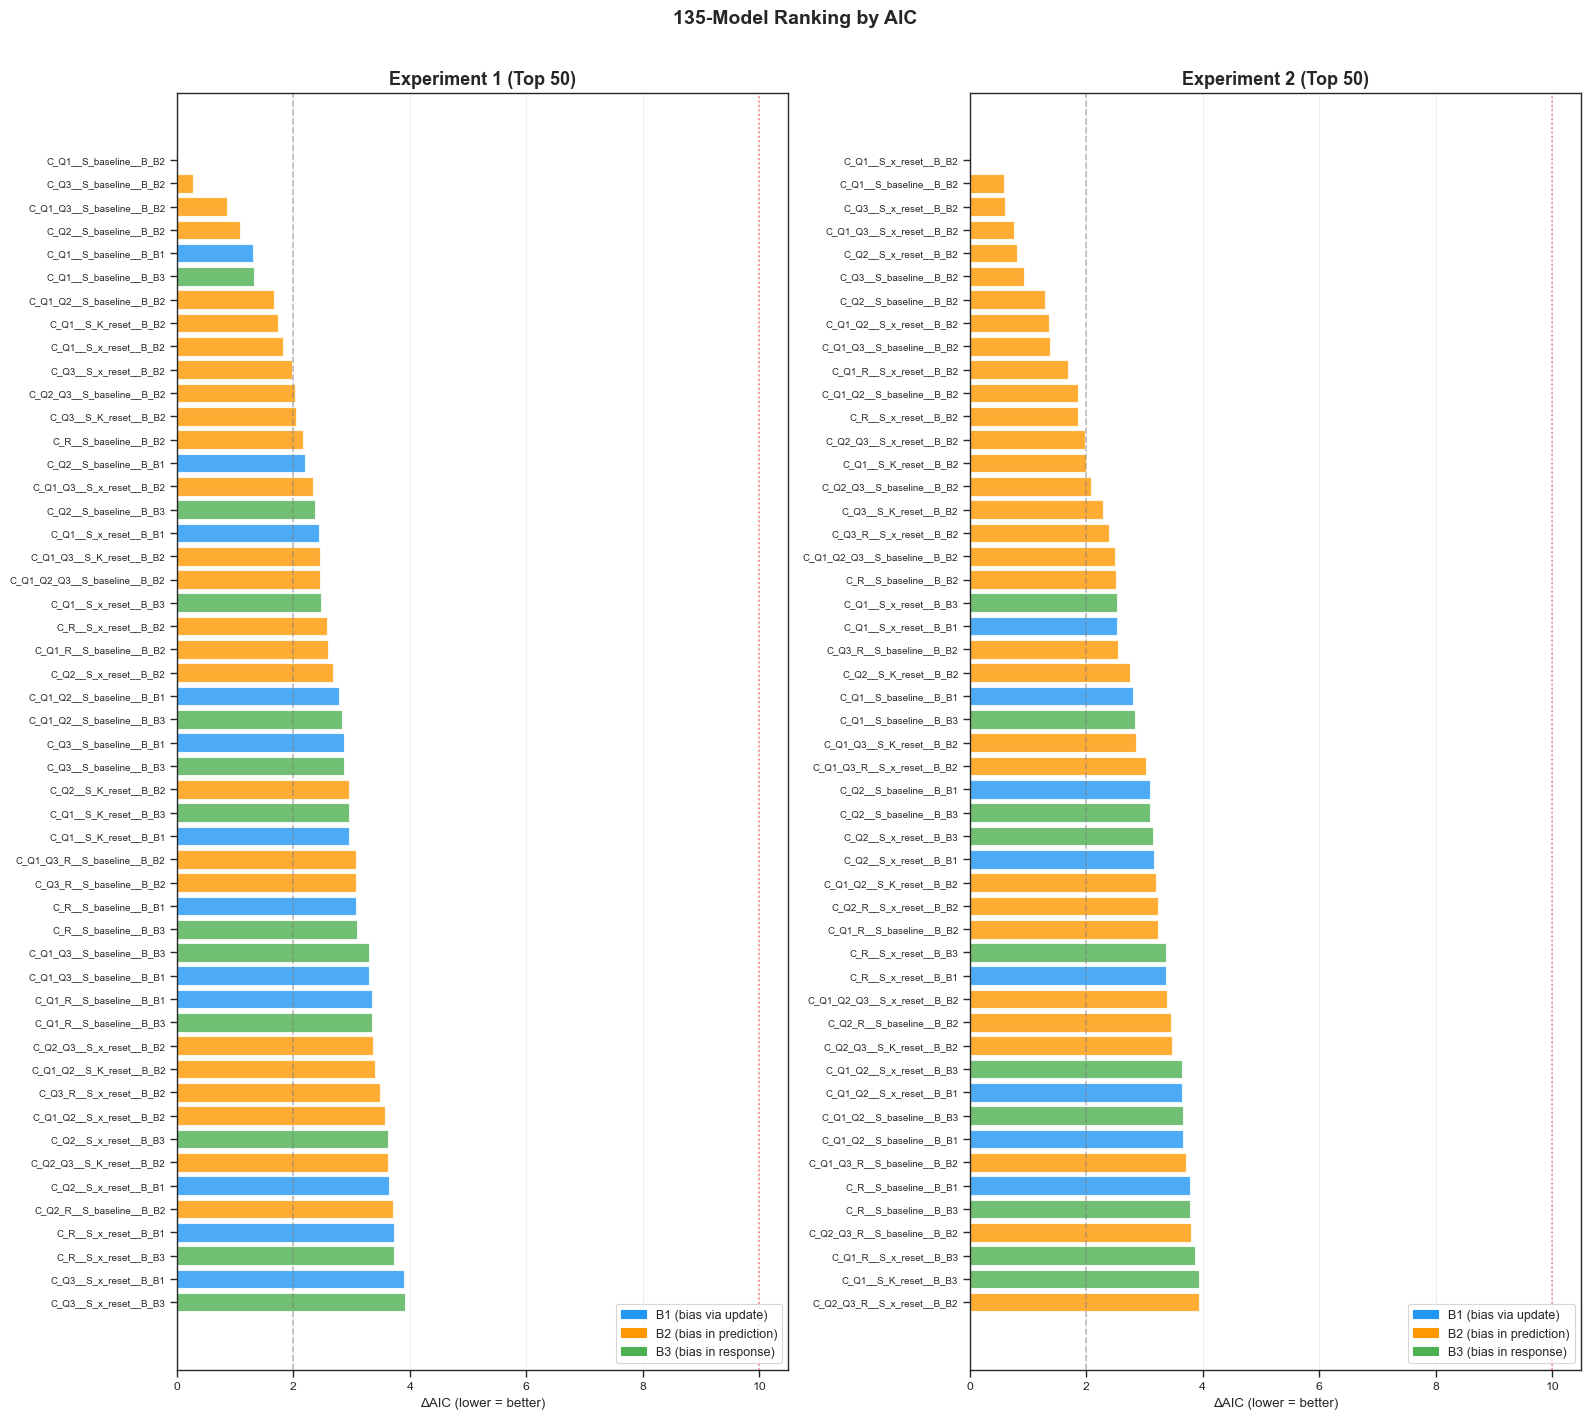

In [85]:
# Delta AIC bar plot
if results_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 14))
    
    # Color mapping for B-axis
    b_colors = {'B1': '#2196F3', 'B2': '#FF9800', 'B3': '#4CAF50'}
    
    for idx, exp_num in enumerate([1, 2]):
        ax = axes[idx]
        ranking = rank_models(results_df, exp_num=exp_num, criterion='AIC')
        
        # Show top 50 for readability
        top_n = ranking.head(50)
        
        # Colors by B-axis
        colors = [b_colors.get(b, 'gray') for b in top_n['b_id']]
        
        ax.barh(range(len(top_n)), top_n['delta_AIC'], color=colors, alpha=0.8)
        ax.set_yticks(range(len(top_n)))
        ax.set_yticklabels(top_n['model_name'], fontsize=7)
        ax.invert_yaxis()
        ax.set_xlabel('ΔAIC (lower = better)')
        ax.set_title(f'Experiment {exp_num} (Top 50)', fontsize=13, fontweight='bold')
        ax.axvline(x=2, color='gray', ls='--', alpha=0.5)
        ax.axvline(x=10, color='red', ls=':', alpha=0.5)
        ax.grid(axis='x', alpha=0.3)
        
        # Legend
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(color='#2196F3', label='B1 (bias via update)'),
            Patch(color='#FF9800', label='B2 (bias in prediction)'),
            Patch(color='#4CAF50', label='B3 (bias in response)'),
        ], loc='lower right', fontsize=9)
    
    plt.suptitle('135-Model Ranking by AIC', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(output_path / 'model_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Posterior Predictive Checks (PPC)

### Central Tendency Index (CTI)
$$\text{CTI} = \text{slope}(r_t \sim s_t)$$

### Serial Dependence Index (SDI)
$$\text{SDI} = \text{slope}(\text{Bias}_t \sim s_{t-1})$$

In [86]:
# PPC helper functions

def compute_cti(duration, reproduction):
    """Central Tendency Index: slope of Reproduction ~ Duration"""
    valid = ~(np.isnan(duration) | np.isnan(reproduction))
    if valid.sum() < 20:
        return np.nan
    return np.polyfit(duration[valid], reproduction[valid], 1)[0]

def compute_sdi(prev_stim, bias):
    """Serial Dependence Index: slope of Bias ~ prev_stim"""
    valid = ~(np.isnan(prev_stim) | np.isnan(bias))
    if valid.sum() < 20:
        return np.nan
    return np.polyfit(prev_stim[valid], bias[valid], 1)[0]

def run_ppc_cti_sdi(data, results_df, exp_num, model_name, verbose=True):
    """Run PPC and compute CTI/SDI recovery for all subjects"""
    exp_data = data[data['exp'] == exp_num]
    # Filter results to this experiment only — prevents cross-exp parameter mixing
    results_exp = results_df[results_df['exp'] == exp_num]
    model_results = results_exp[results_exp['model_name'] == model_name]
    
    obs_metrics, sim_metrics = [], []
    n_failed = 0
    
    for sub in exp_data['Sub'].unique():
        sub_data = exp_data[exp_data['Sub'] == sub].copy()
        params_row = model_results[model_results['Sub'] == sub]
        
        if len(params_row) == 0 or not params_row.iloc[0]['success']:
            continue
        
        try:
            # Pass exp-filtered results_df so PPC uses the correct experiment's parameters
            ppc = generate_ppc_single_subject(sub_data, results_exp, model_name=model_name)
            sim_resp = ppc['pred']
        except Exception as e:
            n_failed += 1
            if verbose and n_failed <= 3:
                print(f'  ⚠ PPC failed for Sub {sub}: {e}')
            continue
        
        # Get previous duration
        prev_dur = sub_data['Duration'].shift(1).values
        
        # Observed
        obs_cti = compute_cti(sub_data['Duration'].values, sub_data['Reproduction'].values)
        obs_sdi = compute_sdi(prev_dur, sub_data['Bias'].values)
        obs_metrics.append({'Sub': sub, 'CTI': obs_cti, 'SDI': obs_sdi})
        
        # Simulated
        sim_cti = compute_cti(sub_data['Duration'].values, sim_resp)
        sim_bias = sim_resp - sub_data['Duration'].values
        sim_sdi = compute_sdi(prev_dur, sim_bias)
        sim_metrics.append({'Sub': sub, 'CTI': sim_cti, 'SDI': sim_sdi})
    
    if verbose and n_failed > 3:
        print(f'  ... and {n_failed - 3} more failures')
    
    if not obs_metrics or not sim_metrics:
        if verbose:
            print(f'  ⚠ No successful PPC results (failed: {n_failed})')
        return pd.DataFrame()
    
    obs_df = pd.DataFrame(obs_metrics)
    sim_df = pd.DataFrame(sim_metrics)
    return obs_df.merge(sim_df, on='Sub', suffixes=('_obs', '_sim'))

print('PPC helper functions defined')

PPC helper functions defined


### Run PPC for Best Models

Generate simulated responses using the best-fitting model for each experiment, then compute CTI and SDI recovery metrics.

In [87]:
# Run PPC for best models
if results_df is not None:
    print('='*80)
    print('PPC: CTI & SDI RECOVERY')
    print('='*80)
    
    # Get best models
    best_exp1, _ = get_best_model(results_df, exp_num=1, criterion='AIC')
    best_exp2, _ = get_best_model(results_df, exp_num=2, criterion='AIC')
    
    print(f'\nBest models:')
    print(f'  Exp1: {best_exp1}')
    print(f'  Exp2: {best_exp2}')
    
    ppc_results = {}
    
    for exp, model in [(1, best_exp1), (2, best_exp2)]:
        print(f'\nRunning PPC for Exp{exp} ({model})...')
        merged = run_ppc_cti_sdi(df, results_df, exp, model)
        
        if len(merged) > 0:
            # Correlations
            cti_r, _ = pearsonr(merged['CTI_obs'].dropna(), merged['CTI_sim'].dropna())
            sdi_r, _ = pearsonr(merged['SDI_obs'].dropna(), merged['SDI_sim'].dropna())
            
            # Recovery
            cti_rec = merged['CTI_sim'].mean() / merged['CTI_obs'].mean() * 100
            sdi_rec = merged['SDI_sim'].mean() / merged['SDI_obs'].mean() * 100
            
            ppc_results[exp] = {
                'merged': merged,
                'CTI_r': cti_r, 'SDI_r': sdi_r,
                'CTI_rec': cti_rec, 'SDI_rec': sdi_rec,
                'model': model
            }
            
            print(f'  CTI: r = {cti_r:.3f}, Recovery = {cti_rec:.0f}%')
            print(f'  SDI: r = {sdi_r:.3f}, Recovery = {sdi_rec:.0f}%')
        else:
            print(f'  ⚠ No valid PPC data for Exp{exp}')
    
    print('\n' + '='*80)
else:
    print('⚠ No results_df available. Run fitting first.')

PPC: CTI & SDI RECOVERY

Best models:
  Exp1: C_Q1__S_baseline__B_B2
  Exp2: C_Q1__S_x_reset__B_B2

Running PPC for Exp1 (C_Q1__S_baseline__B_B2)...
  CTI: r = 0.996, Recovery = 100%
  SDI: r = 0.867, Recovery = 105%

Running PPC for Exp2 (C_Q1__S_x_reset__B_B2)...
  CTI: r = 0.995, Recovery = 102%
  SDI: r = 0.935, Recovery = 104%



### PPC Visualization

Scatter plots comparing observed vs. simulated CTI and SDI for each subject. Dashed line = identity; solid line = linear fit.

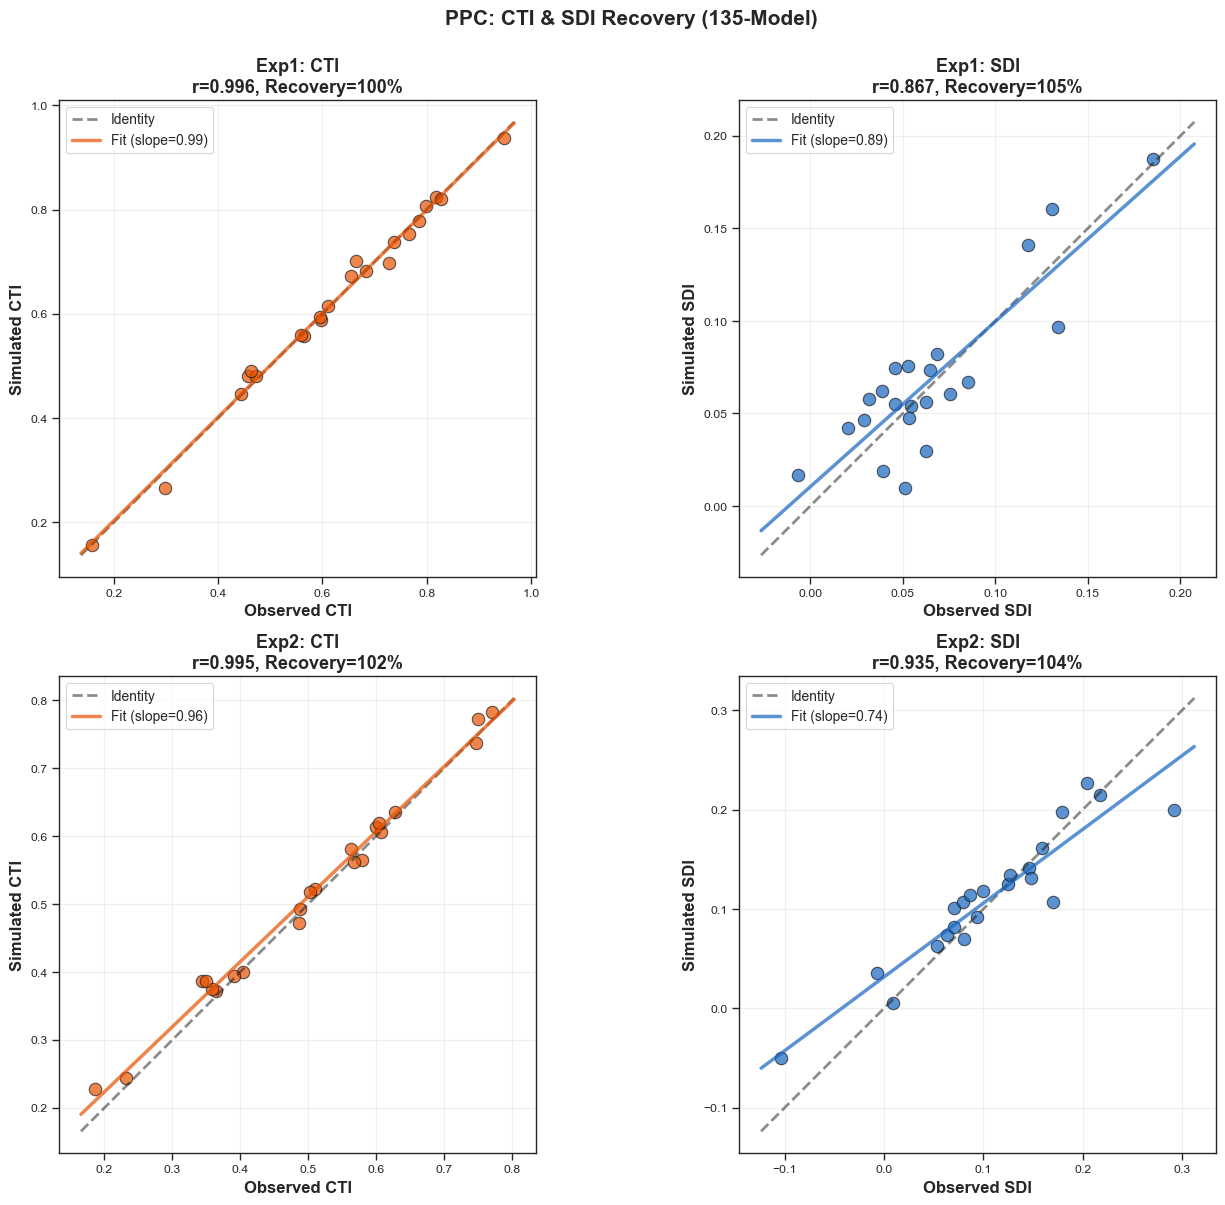

In [88]:
# PPC Scatter Plots (CTI & SDI)
if results_df is not None and ppc_results:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    for exp_idx, exp in enumerate([1, 2]):
        if exp not in ppc_results:
            continue
        res = ppc_results[exp]
        merged = res['merged']
        
        for metric_idx, (metric, color) in enumerate([('CTI', '#E65100'), ('SDI', '#1565C0')]):
            ax = axes[exp_idx, metric_idx]
            valid = merged.dropna(subset=[f'{metric}_obs', f'{metric}_sim'])
            
            x = valid[f'{metric}_obs']
            y = valid[f'{metric}_sim']
            
            # Scatter
            ax.scatter(x, y, s=80, alpha=0.7, color=color, edgecolors='k', lw=0.8)
            
            # Identity line
            lims = [min(x.min(), y.min()) - 0.02, max(x.max(), y.max()) + 0.02]
            ax.plot(lims, lims, 'k--', alpha=0.5, lw=2, label='Identity')
            
            # Regression line
            if len(valid) > 2:
                slope, intercept = np.polyfit(x, y, 1)
                ax.plot(lims, [slope*l + intercept for l in lims], 
                       color=color, lw=2.5, alpha=0.7, label=f'Fit (slope={slope:.2f})')
            
            ax.set_xlabel(f'Observed {metric}', fontsize=12, fontweight='bold')
            ax.set_ylabel(f'Simulated {metric}', fontsize=12, fontweight='bold')
            ax.set_title(f'Exp{exp}: {metric}\nr={res[f"{metric}_r"]:.3f}, Recovery={res[f"{metric}_rec"]:.0f}%',
                        fontsize=13, fontweight='bold')
            ax.legend(frameon=True, fontsize=10)
            ax.grid(alpha=0.3)
            ax.set_aspect('equal', adjustable='box')
    
    plt.suptitle('PPC: CTI & SDI Recovery (135-Model)', 
                 fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(output_path / 'ppc_cti_sdi_recovery.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠ No PPC results available.')

---
## 7. Summary

In [89]:
if results_df is not None:
    print('='*70)
    print('135-MODEL ANALYSIS SUMMARY')
    print('='*70)
    print(f'\nCoherence formula:')
    print(f'  Q(c) = Q_base × exp(α × (1 - c))')
    print(f'  R(c) = 1 if c >= 0.5, r_low if c < 0.5')
    
    for exp_num in [1, 2]:
        best_model, best_data = get_best_model(results_df, exp_num=exp_num)
        mean_aic = best_data['AIC'].mean()
        
        # Parse model name
        c_id = best_data['c_id'].iloc[0]
        s_id = best_data['s_id'].iloc[0]
        b_id = best_data['b_id'].iloc[0]
        
        print(f'\nExperiment {exp_num}:')
        print(f'  Best Model: {best_model}')
        print(f'  C-Axis: {c_id} ({C_AXIS[c_id]["name"]}) - {C_AXIS[c_id]["description"]}')
        print(f'  S-Axis: {s_id} ({S_AXIS[s_id]["name"]}) - {S_AXIS[s_id]["description"]}')
        print(f'  B-Axis: {b_id} ({B_AXIS[b_id]["name"]}) - {B_AXIS[b_id]["description"]}')
        print(f'  Mean AIC: {mean_aic:.2f}')
        print(f'  N params: {best_data["n_params"].iloc[0]}')
        
        # PPC if available
        if exp_num in ppc_results:
            res = ppc_results[exp_num]
            print(f'  PPC CTI: r={res["CTI_r"]:.3f}, Recovery={res["CTI_rec"]:.0f}%')
            print(f'  PPC SDI: r={res["SDI_r"]:.3f}, Recovery={res["SDI_rec"]:.0f}%')
    
    print('\n' + '='*70)

135-MODEL ANALYSIS SUMMARY

Coherence formula:
  Q(c) = Q_base × exp(α × (1 - c))
  R(c) = 1 if c >= 0.5, r_low if c < 0.5

Experiment 1:
  Best Model: C_Q1__S_baseline__B_B2
  C-Axis: C1 (Q1) - Fast state process noise modulated
  S-Axis: S0 (baseline) - No task switching effect
  B-Axis: B2 (B2) - Bias in prediction via F (F[0,2]=1, response=μ+d0)
  Mean AIC: -112.87
  N params: 8
  PPC CTI: r=0.996, Recovery=100%
  PPC SDI: r=0.867, Recovery=105%

Experiment 2:
  Best Model: C_Q1__S_x_reset__B_B2
  C-Axis: C1 (Q1) - Fast state process noise modulated
  S-Axis: S1 (x_reset) - Switch resets slow state toward prior mean
  B-Axis: B2 (B2) - Bias in prediction via F (F[0,2]=1, response=μ+d0)
  Mean AIC: -73.05
  N params: 9
  PPC CTI: r=0.995, Recovery=102%
  PPC SDI: r=0.935, Recovery=104%



### 7.1 Serial Dependence by Condition

Compare observed vs. simulated serial dependence (Bias ~ previous duration) across experimental conditions:
- **Experiment 1**: Repeat vs. Switch (task structure)
- **Experiment 2**: Low vs. High coherence

SERIAL DEPENDENCE BY CONDITION

Exp1: C_Q1__S_baseline__B_B2


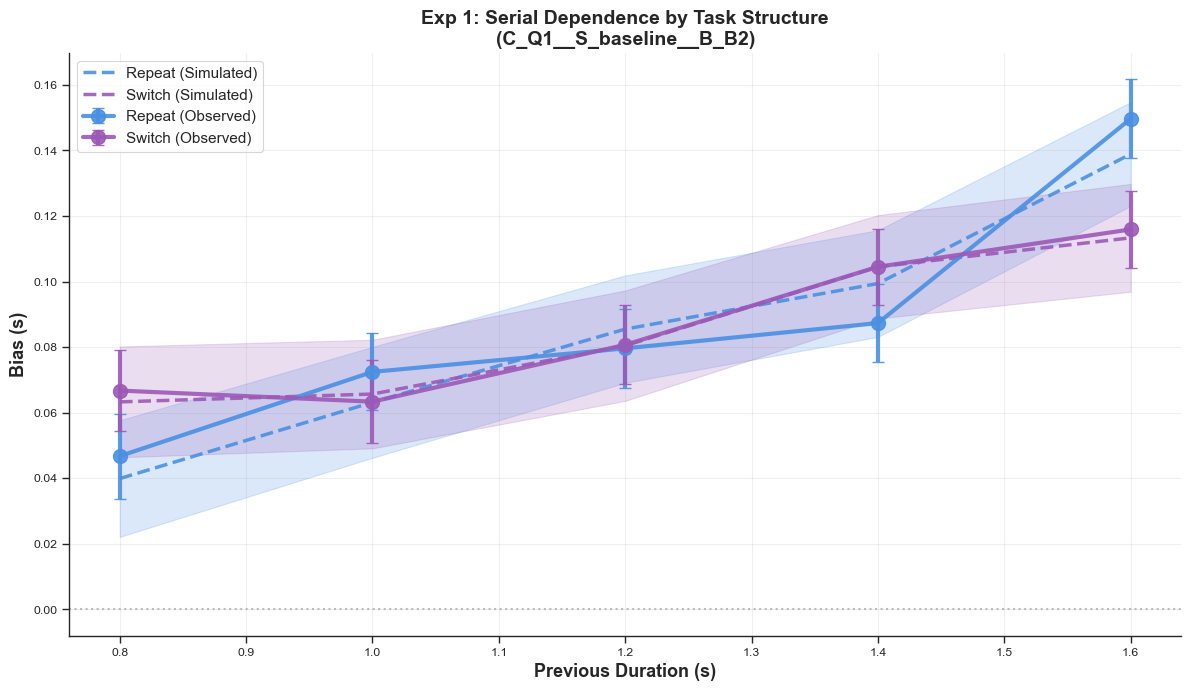


Exp2: C_Q1__S_x_reset__B_B2


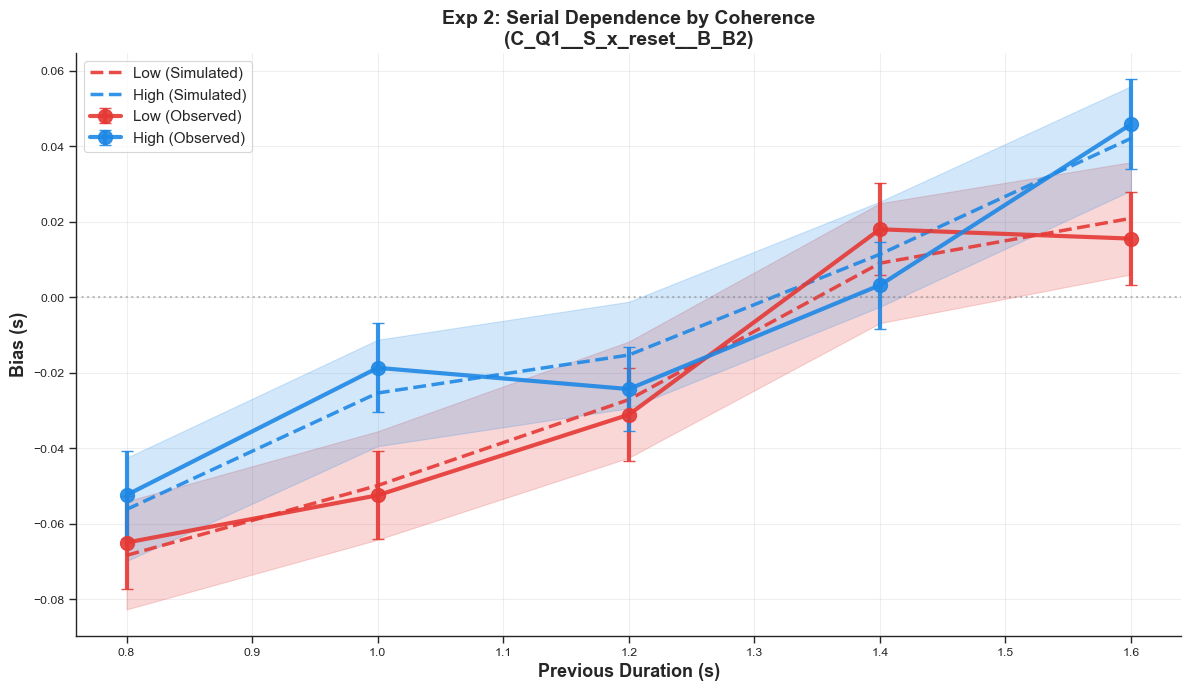

In [90]:
# Serial Dependence by Condition (Observed vs Simulated)
def plot_sd_by_condition(data, results_df, exp_num, model_name):
    """Plot serial dependence (Bias ~ prev_stim) by condition"""
    exp_data = data[data['exp'] == exp_num].copy()
    results_exp = results_df[results_df['exp'] == exp_num]
    model_results = results_exp[results_exp['model_name'] == model_name]
    
    # Generate simulated data
    sim_data_list = []
    for sub in exp_data['Sub'].unique():
        sub_data = exp_data[exp_data['Sub'] == sub].copy()
        params = model_results[model_results['Sub'] == sub]
        
        if len(params) == 0 or not params.iloc[0]['success']:
            continue
        
        try:
            ppc = generate_ppc_single_subject(sub_data, results_exp, model_name=model_name)
            sub_data['sim_resp'] = ppc['pred']
            sub_data['sim_bias'] = ppc['pred'] - sub_data['Duration'].values
            sub_data['preDur'] = sub_data['Duration'].shift(1)
            sim_data_list.append(sub_data)
        except:
            continue
    
    if not sim_data_list:
        print(f'No simulation data for Exp{exp_num}')
        return None
    
    sim_data = pd.concat(sim_data_list, ignore_index=True)
    exp_data['preDur'] = exp_data.groupby('Sub')['Duration'].shift(1)
    
    # Setup conditions
    if exp_num == 1:
        cond_col = 'Structure'
        conds = ['Repeat', 'Switch']
        colors = ['#4A90E2', '#9B59B6']
        title_suffix = 'Task Structure'
    else:
        exp_data['coh_cat'] = np.where(exp_data['coherence'] < 0.5, 'Low', 'High')
        sim_data['coh_cat'] = np.where(sim_data['coherence'] < 0.5, 'Low', 'High')
        cond_col = 'coh_cat'
        conds = ['Low', 'High']
        colors = ['#E53935', '#1E88E5']
        title_suffix = 'Coherence'
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    for i, cond in enumerate(conds):
        obs_cond = exp_data[exp_data[cond_col] == cond]
        obs_cond = obs_cond.dropna(subset=['preDur', 'Bias'])
        if len(obs_cond) > 0:
            g_obs = obs_cond.groupby('preDur')['Bias'].agg(['mean', 'sem']).reset_index()
            ax.errorbar(g_obs['preDur'], g_obs['mean'], yerr=g_obs['sem'],
                       marker='o', ls='-', color=colors[i], label=f'{cond} (Observed)', 
                       capsize=4, lw=3, ms=10, alpha=0.9)
        
        sim_cond = sim_data[sim_data[cond_col] == cond]
        sim_cond = sim_cond.dropna(subset=['preDur', 'sim_bias'])
        if len(sim_cond) > 0:
            g_sim = sim_cond.groupby('preDur')['sim_bias'].agg(['mean', 'sem']).reset_index()
            g_sim = g_sim.sort_values('preDur')
            ci_lower = g_sim['mean'] - 1.96 * g_sim['sem']
            ci_upper = g_sim['mean'] + 1.96 * g_sim['sem']
            ax.fill_between(g_sim['preDur'], ci_lower, ci_upper, color=colors[i], alpha=0.2)
            ax.plot(g_sim['preDur'], g_sim['mean'], ls='--', color=colors[i], lw=2.5, alpha=0.9,
                   label=f'{cond} (Simulated)')
    
    ax.axhline(0, color='gray', ls=':', alpha=0.5, lw=1.5)
    ax.set_xlabel('Previous Duration (s)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Bias (s)', fontsize=13, fontweight='bold')
    ax.set_title(f'Exp {exp_num}: Serial Dependence by {title_suffix}\n({model_name})', 
                fontsize=14, fontweight='bold')
    ax.legend(frameon=True, fontsize=11, loc='best')
    ax.grid(alpha=0.3)
    sns.despine(ax=ax)
    plt.tight_layout()
    return fig

# Plot for both experiments
if results_df is not None:
    print('='*70)
    print('SERIAL DEPENDENCE BY CONDITION')
    print('='*70)
    
    best_exp1, _ = get_best_model(results_df, exp_num=1, criterion='AIC')
    best_exp2, _ = get_best_model(results_df, exp_num=2, criterion='AIC')
    
    print(f'\nExp1: {best_exp1}')
    fig1 = plot_sd_by_condition(df, results_df, exp_num=1, model_name=best_exp1)
    if fig1:
        fig1.savefig(output_path / 'sd_by_condition_exp1_linear.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'\nExp2: {best_exp2}')
    fig2 = plot_sd_by_condition(df, results_df, exp_num=2, model_name=best_exp2)
    if fig2:
        fig2.savefig(output_path / 'sd_by_condition_exp2_linear.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠ No results_df available.')